# Conversión Digital a Analógico (DAC) y Procesamiento Multitasa
 
En este notebook analizaremos dos operaciones fundamentales en el procesamiento discreto de señales:
1. **Diezmado (Decimation - $M\downarrow$):** Reducción de la tasa de muestreo.
2. **Interpolación (Interpolation - $L\uparrow$):** Aumento de la tasa de muestreo mediante inserción de ceros y filtrado anti-imaging.

Finalmente, veremos cómo la **Interpolación Digital** se utiliza en los **Interpolating DACs** para relajar las exigencias del filtro analógico de reconstrucción pasabajo a la salida del conversor.


## 1. Diezmado (Decimation / Downsampling)
 
El diezmado consiste en reducir la frecuencia de muestreo de una señal por un factor entero $M$.

**Proceso:**
1. Conservar 1 de cada $M$ muestras ($y[m] = x[mM]$).
2. **Efecto en Frecuencia:** El espectro se **expande/ensancha** por un factor $M$.
3. **Riesgo de Aliasing:** Para evitar aliasing, la señal debe ser filtrada previamente con un LPF digital con frecuencia de corte $\omega_c = \pi / M$.

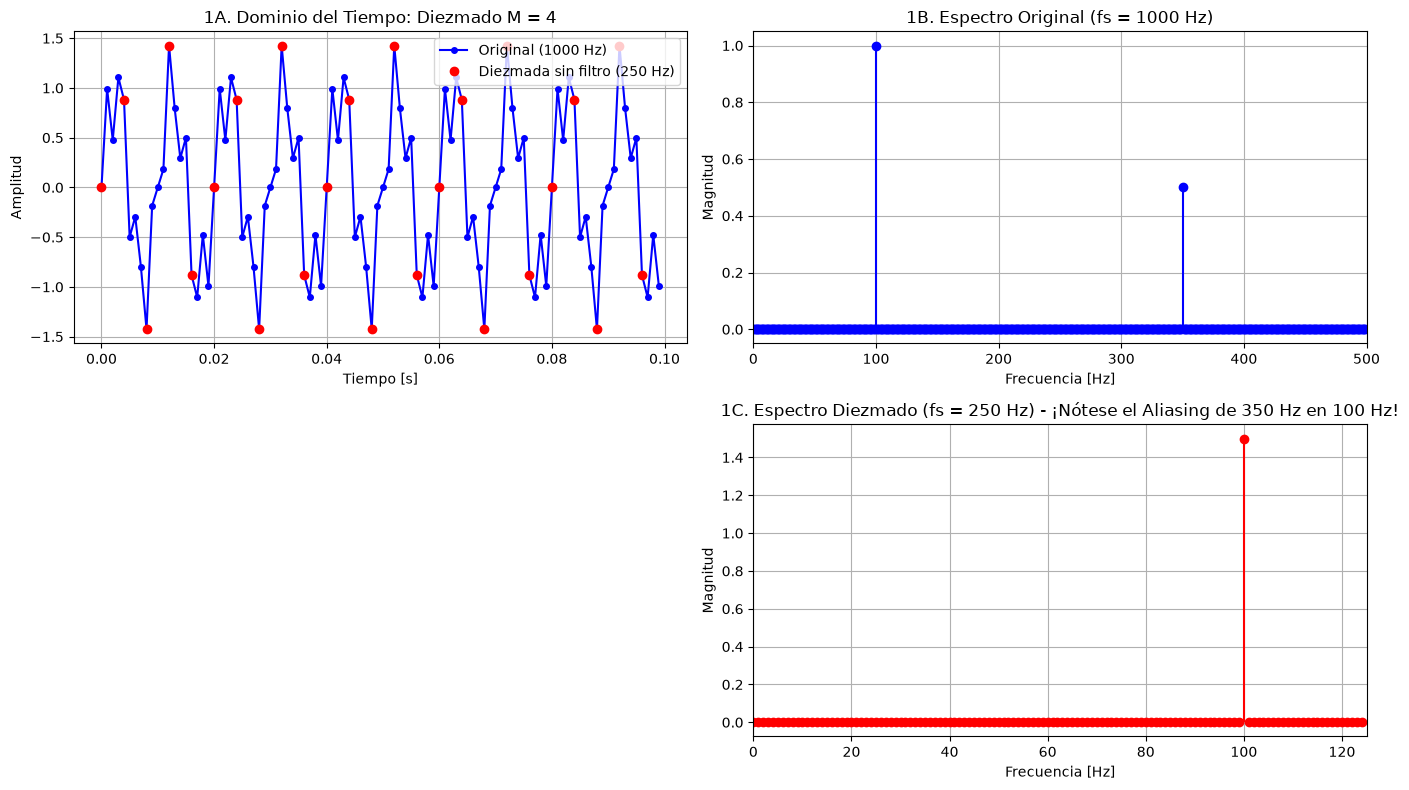

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Estilo gráfico claro
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 10

# Parámetros para la simulación
fs_orig = 1000  # Frecuencia de muestreo inicial [Hz]
N = 1000        # Número de muestras
t = np.arange(N) / fs_orig

# Señal compuesta con dos componentes frecuenciales (100 Hz y 350 Hz)
f1, f2 = 100, 350
x = np.sin(2 * np.pi * f1 * t) + 0.5 * np.sin(2 * np.pi * f2 * t)

# Factor de diezmado
M = 4
fs_diezmada = fs_orig / M  # 250 Hz -> Nueva Frecuencia de Nyquist = 125 Hz

# Submuestreo directo (Sin filtro anti-aliasing -> Genera Aliasing de f2 = 350 Hz)
x_down_direct = x[::M]

# Función auxiliar para calcular la FFT en dB
def calcular_fft(signal, fs):
    N_fft = len(signal)
    freqs = np.fft.fftfreq(N_fft, 1/fs)[:N_fft//2]
    fft_val = np.abs(np.fft.fft(signal))[:N_fft//2] * (2 / N_fft)
    return freqs, fft_val

# Gráficos
fig, axs = plt.subplots(2, 2, figsize=(14, 8))

# Dominio del Tiempo
axs[0, 0].plot(t[:100], x[:100], 'b-o', label='Original (1000 Hz)', markersize=4)
axs[0, 0].plot(t[:100:M], x_down_direct[:100//M], 'ro', label='Diezmada sin filtro (250 Hz)', markersize=6)
axs[0, 0].set_title('1A. Dominio del Tiempo: Diezmado M = 4')
axs[0, 0].set_xlabel('Tiempo [s]')
axs[0, 0].set_ylabel('Amplitud')
axs[0, 0].legend()

# Dominio de la Frecuencia
f_orig, spec_orig = calcular_fft(x, fs_orig)
f_down, spec_down = calcular_fft(x_down_direct, fs_diezmada)

axs[0, 1].stem(f_orig, spec_orig, linefmt='b-', markerfmt='bo', basefmt=' ')
axs[0, 1].set_title('1B. Espectro Original (fs = 1000 Hz)')
axs[0, 1].set_xlabel('Frecuencia [Hz]')
axs[0, 1].set_ylabel('Magnitud')
axs[0, 1].set_xlim(0, fs_orig/2)

axs[1, 1].stem(f_down, spec_down, linefmt='r-', markerfmt='ro', basefmt=' ')
axs[1, 1].set_title('1C. Espectro Diezmado (fs = 250 Hz) - ¡Nótese el Aliasing de 350 Hz en 100 Hz!')
axs[1, 1].set_xlabel('Frecuencia [Hz]')
axs[1, 1].set_ylabel('Magnitud')
axs[1, 1].set_xlim(0, fs_diezmada/2)

axs[1, 0].axis('off')
plt.tight_layout()
plt.show()



## 2. Interpolación (Interpolation / Upsampling)

La interpolación consiste en aumentar la tasa de muestreo por un factor entero $L$.

**Pasos Matemáticos:**
1. **Inserción de Ceros (Upsampling $L\uparrow$):** Insertar $L-1$ ceros entre cada muestra original.
   $$x_u[m] = \begin{cases} x[m/L], & \text{si } m \text{ es múltiplo de } L \\ 0, & \text{en otro caso} \end{cases}$$
    *Efecto en frecuencia:* Comprime la escala en frecuencia y genera $L-1$ **imágenes espectrales / réplicas** no deseadas en la banda base ampliada.
 2. **Filtrado Anti-Imaging (LPF Digital):** Un filtro pasabajo digital elimina las imágenes espectrales intermedias, realizando la interpolación suave de los valores.


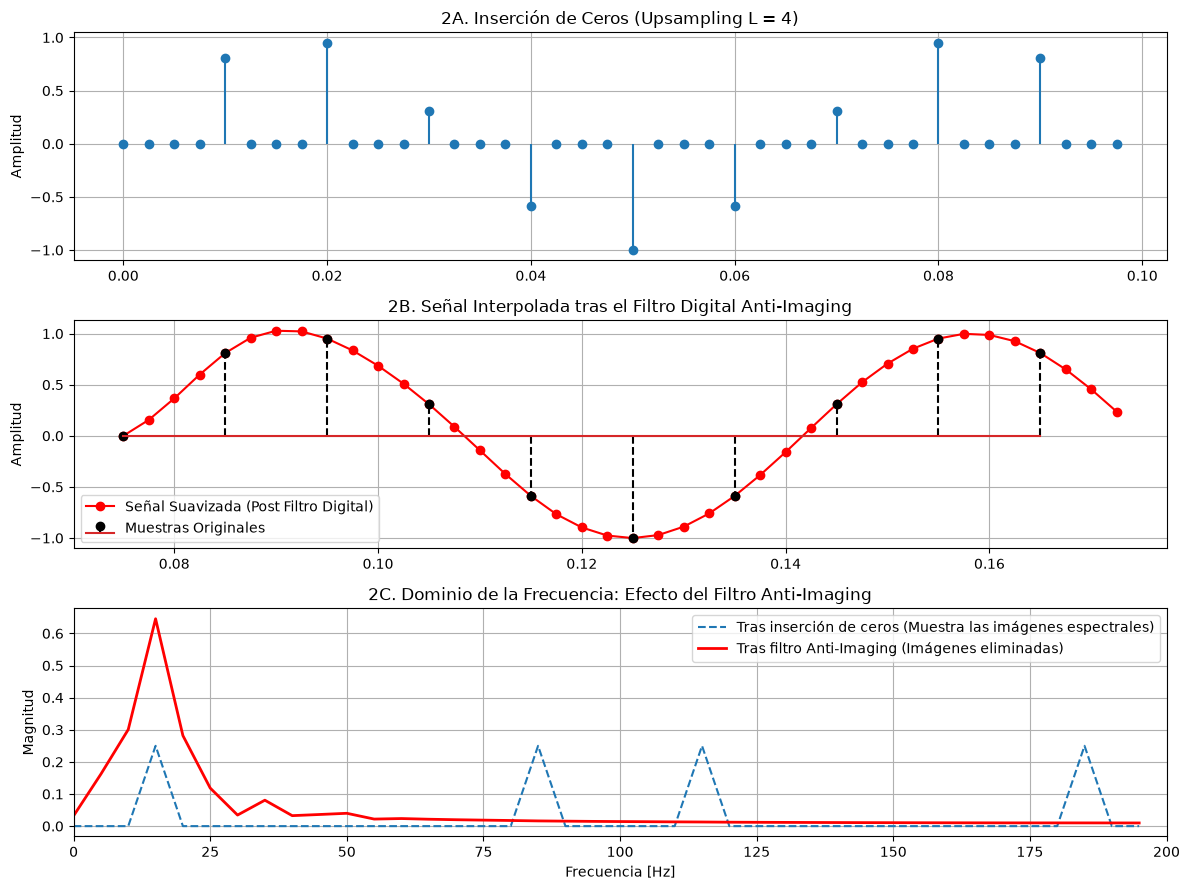

In [29]:

# Señal discreta base
fs_base = 100  # Hz
t_base = np.arange(0, 0.2, 1/fs_base)
f_sig = 15     # Hz
x_base = np.sin(2 * np.pi * f_sig * t_base)

# Factor de interpolación
L = 4
fs_interpolada = fs_base * L # 400 Hz

# Paso 1: Inserción de Ceros (Upsampling)
x_zeros = np.zeros(len(x_base) * L)
x_zeros[::L] = x_base

# Paso 2: Filtro Anti-Imaging (Simulado con una ventana Sinc / FIR Pasabajo)
from scipy.signal import firwin, lfilter

# Diseño del filtro pasabajo con corte en fs_base / 2
num_taps = 61
h_lpf = firwin(num_taps, cutoff=(fs_base / 2), fs=fs_interpolada)
x_interpolada = lfilter(h_lpf, 1, x_zeros) * L  # Ganancia L para compensar la energía

# Gráficos de Interpolación
fig, axs = plt.subplots(3, 1, figsize=(12, 9))

# A. Inserción de ceros en tiempo
t_zeros = np.arange(len(x_zeros)) / fs_interpolada
axs[0].stem(t_zeros[:40], x_zeros[:40], linefmt='C0-', markerfmt='C0o', basefmt=' ')
axs[0].set_title(f'2A. Inserción de Ceros (Upsampling L = {L})')
axs[0].set_ylabel('Amplitud')

# B. Salida filtrada (Señal Interpolada)
axs[1].plot(t_zeros[num_taps//2:40+num_taps//2], x_interpolada[num_taps//2:40+num_taps//2],'r-o', label='Señal Suavizada (Post Filtro Digital)')
axs[1].stem(t_base[:10]+0.075, x_base[:10], linefmt='k--', markerfmt='ko', label='Muestras Originales')
axs[1].set_title('2B. Señal Interpolada tras el Filtro Digital Anti-Imaging')
axs[1].set_ylabel('Amplitud')
axs[1].legend()

# C. Comparación espectral
f_z, spec_z = calcular_fft(x_zeros, fs_interpolada)
f_i, spec_i = calcular_fft(x_interpolada, fs_interpolada)

axs[2].plot(f_z, spec_z, 'C0--', label='Tras inserción de ceros (Muestra las imágenes espectrales)')
axs[2].plot(f_i, spec_i, 'r-', linewidth=2, label='Tras filtro Anti-Imaging (Imágenes eliminadas)')
axs[2].set_title('2C. Dominio de la Frecuencia: Efecto del Filtro Anti-Imaging')
axs[2].set_xlabel('Frecuencia [Hz]')
axs[2].set_ylabel('Magnitud')
axs[2].set_xlim(0, fs_interpolada/2)
axs[2].legend()

plt.tight_layout()
plt.show()


## 3. El "Interpolating DAC" y la Relajación del Filtro Analógico

### ¿Por qué interpolar antes de convertir a analógico?
En un DAC Nyquist estándar a frecuencia $f_s$:
* Las **imágenes espectrales** aparecen muy cerca de la banda base (a $f_s - f_{max}$).
* Esto requiere un **filtro analógico reconstructor muy complejo** (alto orden, corte abrupto, distorsión de fase).
 
Al utilizar un **Interpolating DAC**:
1. Aumentamos digitalmente la tasa de muestreo a $L \cdot f_s$.
2. Las réplicas espectrales se desplazan a frecuencias mucho más altas ($L \cdot f_s - f_{max}$).
3. La banda de transición del filtro analógico se vuelve muy ancha, **relajando la exigencia del filtro de salida** a un circuito analógico simple (1er o 2do orden).

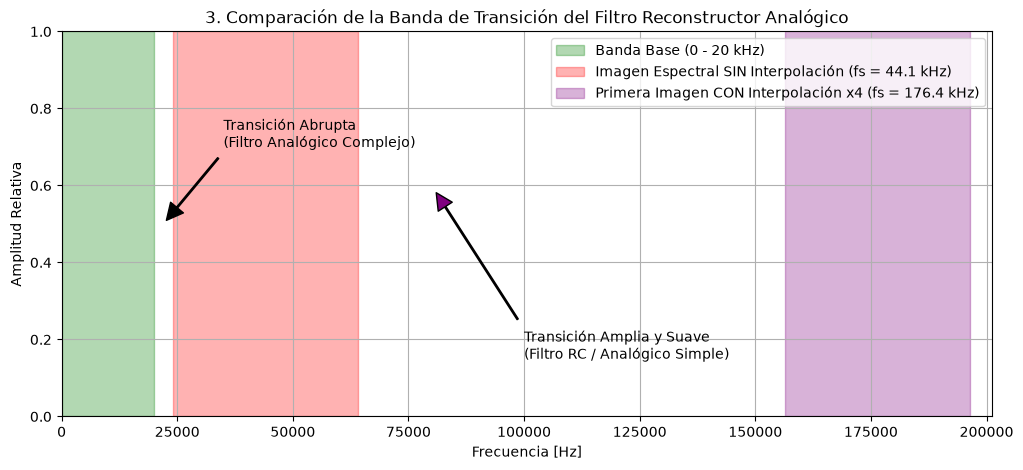

In [40]:
# Demostración práctica de la relajación del filtro
fs_audio = 44100      # Tasa de audio estándar
f_audio_max = 20000   # Frecuencia máxima útil (20 kHz)
L_oversample = 4      # Factor de interpolación
fs_dac = fs_audio * L_oversample # 176.4 kHz

freqs_norm = np.linspace(0, fs_dac/2, 2000)

# Espectro conceptual sin interpolación (imágenes en 44.1k - 20k = 24.1 kHz)
# Espectro conceptual con interpolación (imágenes desplazadas a 176.4k - 20k = 156.4 kHz)

plt.figure(figsize=(12, 5))

# Representación de la banda base
plt.axvspan(0, f_audio_max, color='green', alpha=0.3, label='Banda Base (0 - 20 kHz)')

# Réplica Sin Interpolación
plt.axvspan(fs_audio - f_audio_max, fs_audio + f_audio_max, color='red', alpha=0.3, 
            label='Imagen Espectral SIN Interpolación (fs = 44.1 kHz)')

# Réplica Con Interpolación x4
plt.axvspan(fs_dac - f_audio_max, fs_dac + f_audio_max, color='purple', alpha=0.3, 
            label='Primera Imagen CON Interpolación x4 (fs = 176.4 kHz)')

# Máscaras de filtros analógicos requeridos
# Filtro Exigente (Sin Interpolación): Debe atenuar entre 20 kHz y 24.1 kHz
plt.annotate('Transición Abrupta\n(Filtro Analógico Complejo)', 
             xy=(22000, 0.5), xytext=(35000, 0.7),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))

# Filtro Relajado (Con Interpolación): Puede atenuar suavemente entre 20 kHz y 156.4 kHz
plt.annotate('Transición Amplia y Suave\n(Filtro RC / Analógico Simple)', 
             xy=(80000, 0.6), xytext=(100000, 0.15),
             arrowprops=dict(facecolor='purple', shrink=0.05, width=1))

plt.title('3. Comparación de la Banda de Transición del Filtro Reconstructor Analógico')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitud Relativa')
plt.xlim(0, fs_dac*1.14)
plt.ylim(0, 1)
plt.legend(loc='upper right')
plt.grid(True)
plt.show()